##Modelos de Deep Learning para Clasificación

En este notebook se continúa el trabajo iniciado previamente con modelos de Machine Learning, donde se abordó la clasificación de mensajes de un chat mediante técnicas como TF-IDF y distintos algoritmos clásicos.

En esta segunda fase, se incorporan modelos de Deep Learning con el objetivo de analizar si son capaces de capturar mejor el estilo de escritura de cada usuario y mejorar el rendimiento en la tarea de clasificación. Este problema presenta una dificultad añadida debido a la similitud en el vocabulario entre los participantes y la corta longitud de muchos mensajes.

A lo largo del notebook, se entrenarán y evaluarán diferentes modelos basados en redes neuronales, analizando su comportamiento mediante métricas como la accuracy y la loss, así como la posible aparición de overfitting.

In [1]:
# LIBRERÍAS BÁSICAS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PREPROCESAMIENTO TEXTO

import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# MÉTRICAS

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# KERAS / TENSORFLOW (RNN, LSTM, GRU)

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# TRANSFORMERS (BERT / DISTILBERT)

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Se fijaron semillas aleatorias para garantizar la reproducibilidad de los experimentos.

In [3]:
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [4]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/TRABAJO_NO_ESTRUCTURADOS/data/dataframe_limpio.csv')
df.head(6)

,timestamp,person,message,message_length_words,message_length_chars
0,2022-07-10 20:14:08,Paula,Me estoy agobiando con los grupos,6,33
1,2022-07-10 20:14:12,Paula,Asiq hablamos por aqui,4,22
2,2022-07-10 20:14:12,Carmen,Coño,1,4
3,2022-07-10 20:14:14,Carmen,Gracias,1,7
4,2022-07-10 20:14:15,Carmen,Jajjjajajj,1,10
5,2022-07-10 20:14:38,Carmen,A ver,2,5


### Preprocesamiento para todos los modelos

In [8]:
print(df["message"].isna().sum())

0


In [9]:
import re

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'\d+', '', texto)  # quitar números
    texto = re.sub(r'[^\w\s]', '', texto)  # quitar símbolos/emojis
    return texto

df["message"] = df["message"].apply(limpiar_texto)

In [10]:
print(df["message"].isna().sum())

0


Con el objetivo de mejorar el rendimiento de los modelos, se ha decidido agrupar los mensajes consecutivos de un mismo usuario, generando así secuencias de mayor longitud y preservando el contexto conversacional:

In [11]:
# Crear una serie que indique cuándo empieza un nuevo bloque de conversación
# (cuando cambia la persona respecto al mensaje anterior o es el primer mensaje)
is_new_block = (df['person'] != df['person'].shift(1)).fillna(True)

# Crear un identificador único para cada bloque continuo de mensajes de la misma persona
conversation_block_id = is_new_block.cumsum()

# Agrupar por ese identificador y combinar los mensajes
df_combined_messages = df.groupby(conversation_block_id).agg(
    timestamp=('timestamp', 'first'),  # Mantener el timestamp del primer mensaje del bloque
    person=('person', 'first'),        # Mantener la persona que escribió ese bloque
    message_combined=('message', ' '.join)  # Unir todos los mensajes del bloque en uno solo
)

# Resetear el índice para dejar el DataFrame limpio (sin el índice temporal)
df = df_combined_messages.reset_index(drop=True)

# Ver las primeras filas del DataFrame con mensajes combinados
print(df[['person', 'message_combined']].head(10))

   person                                   message_combined
0   Paula  me estoy agobiando con los grupos asiq hablamo...
1  Carmen  coño gracias jajjjajajj a ver si solo hay un v...
2   Paula                      yo voy al baño y voy para all
3  Carmen                aunq la gente suele pedir por glovo
4   Paula                           asiq me da igual la hora
5  Carmen                          pero igualmente es madrid
6   Paula                            sisi tienes razon  alli
7  Carmen  por mi sii es mas si te descuidas se puede res...
8   Paula  vale hay varios en madrid eh no creo tia yo cr...
9  Angela                                llamo para reservar


In [12]:
print(df["message_combined"].isna().sum())

0


In [ ]:
df.to_csv('/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/data/dataframe_concatenado.csv', index=False)

In [13]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["person"])

print("Clases:", list(label_encoder.classes_))
print(df["person"].value_counts())

Clases: ['Angela', 'Carmen', 'Claudia', 'Paula']
person
Claudia    8870
Paula      8437
Carmen     7219
Angela     5788
Name: count, dtype: int64


In [14]:
X = df["message_combined"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# reset index
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [13]:
def plot_confusion(y_true, y_pred, title, labels):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
                xticklabels=labels,
                yticklabels=labels)

    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()

Se limita el tamaño del vocabulario a las palabras más frecuentes para reducir la complejidad del modelo y mejorar su capacidad de generalización:

In [14]:
# TOKENIZER

max_words = 10000
max_len = 20

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

vocab_size = min(max_words, len(tokenizer.word_index) + 1)

print("Vocab size:", vocab_size)

Vocab size: 10000


## 1º RNN

In [ ]:
# 2. MODELO RNN

tf.keras.backend.clear_session()

model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, input_length=max_len),
    SimpleRNN(64),

    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(len(set(y_train)), activation="softmax")
])

model_rnn.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


# 3. EARLY STOPPING

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


# 4. ENTRENAMIENTO

history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

model_rnn.summary()

Epoch 1/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.3517 - loss: 1.3206 - val_accuracy: 0.4694 - val_loss: 1.1826
Epoch 2/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.5512 - loss: 1.0690 - val_accuracy: 0.4971 - val_loss: 1.1642
Epoch 3/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.6960 - loss: 0.8015 - val_accuracy: 0.4715 - val_loss: 1.3304
Epoch 4/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.7652 - loss: 0.6305 - val_accuracy: 0.4846 - val_loss: 1.3667
Epoch 5/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.7934 - loss: 0.5487 - val_accuracy: 0.4646 - val_loss: 1.5915


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,044,942 (11.62 MB)

 Trainable params: 1,014,980 (3.87 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,029,962 (7.74 MB)


RNN - Loss: 1.1642
RNN - Accuracy: 0.4971
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification report RNN:
              precision    recall  f1-score   support

      Angela       0.62      0.55      0.58      1158
      Carmen       0.43      0.45      0.44      1444
     Claudia       0.46      0.48      0.47      1774
       Paula       0.53      0.52      0.52      1687

    accuracy                           0.50      6063
   macro avg       0.51      0.50      0.50      6063
weighted avg       0.50      0.50      0.50      6063



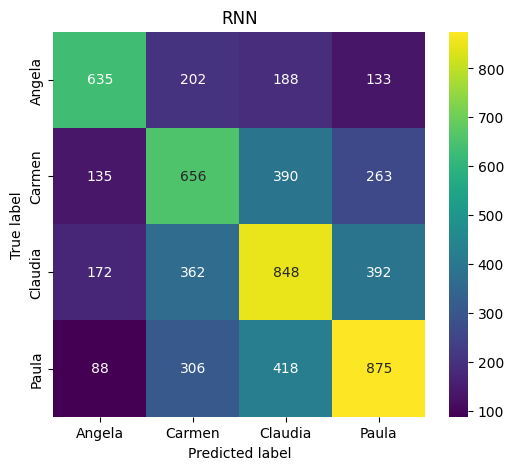

In [ ]:
# 5. EVALUACIÓN

loss_rnn, acc_rnn = model_rnn.evaluate(X_test_pad, y_test, verbose=0)

print(f"\nRNN - Loss: {loss_rnn:.4f}")
print(f"RNN - Accuracy: {acc_rnn:.4f}")

y_pred_probs = model_rnn.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification report RNN:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

plot_confusion(y_test, y_pred, "RNN", label_encoder.classes_)

El modelo alcanza una accuracy del 50%. El F1-score, que combina precisión y recall en una única métrica, presenta valores equilibrados entre clases, situándose en torno a 0.50.

Se observa que algunos usuarios, como Angela, presentan un estilo más fácilmente reconocible, mientras que otros, como Carmen, resultan más difíciles de clasificar.

La matriz de confusión muestra una alta confusión entre ciertas clases, especialmente entre Claudia y Paula, lo que sugiere similitudes en su estilo de escritura.

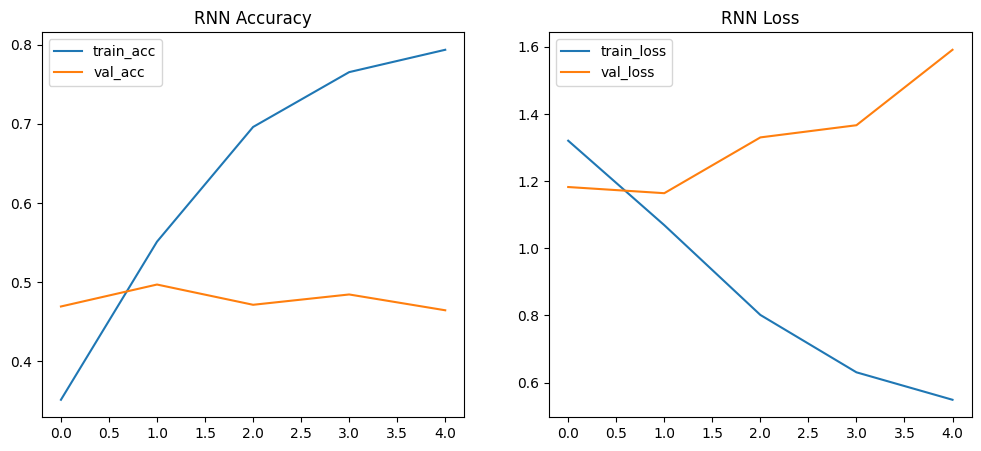

In [ ]:
# 6. CURVAS

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_rnn.history["accuracy"], label="train_acc")
plt.plot(history_rnn.history["val_accuracy"], label="val_acc")
plt.title("RNN Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_rnn.history["loss"], label="train_loss")
plt.plot(history_rnn.history["val_loss"], label="val_loss")
plt.title("RNN Loss")
plt.legend()

plt.show()

Se observa un claro caso de overfitting, ya que la curva de entrenamiento continúa mejorando mientras que la de validación empeora, lo que indica que el modelo está memorizando los datos de entrenamiento y no generaliza correctamente.

## 2º RNN

Para intentar mitigar el problema del overfitting, se prueba una nueva configuración del modelo ajustando distintos parámetros, como el incremento del dropout a 0.5, la reducción de la paciencia del early stopping a 2 y la disminución del número de unidades en la capa recurrente a 32.

In [ ]:
# 2. MODELO RNN

tf.keras.backend.clear_session()

model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, input_length=max_len),
    SimpleRNN(32),

    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(len(set(y_train)), activation="softmax")
])

model_rnn.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


# 3. EARLY STOPPING

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


# 4. ENTRENAMIENTO

history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 33s 32ms/step - accuracy: 0.3296 - loss: 1.3264 - val_accuracy: 0.4212 - val_loss: 1.2632
Epoch 2/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.5065 - loss: 1.1127 - val_accuracy: 0.4455 - val_loss: 1.2263
Epoch 3/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6203 - loss: 0.9336 - val_accuracy: 0.4668 - val_loss: 1.2724
Epoch 4/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.6954 - loss: 0.7859 - val_accuracy: 0.4529 - val_loss: 1.3813


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         4,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,019,886 (11.52 MB)

 Trainable params: 1,006,628 (3.84 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,013,258 (7.68 MB)


RNN - Loss: 1.2263
RNN - Accuracy: 0.4455
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

Classification report RNN:
              precision    recall  f1-score   support

      Angela       0.63      0.29      0.40      1235
      Carmen       0.47      0.51      0.49      1337
     Claudia       0.47      0.25      0.33      1856
       Paula       0.39      0.73      0.51      1635

    accuracy                           0.45      6063
   macro avg       0.49      0.45      0.43      6063
weighted avg       0.48      0.45      0.43      6063



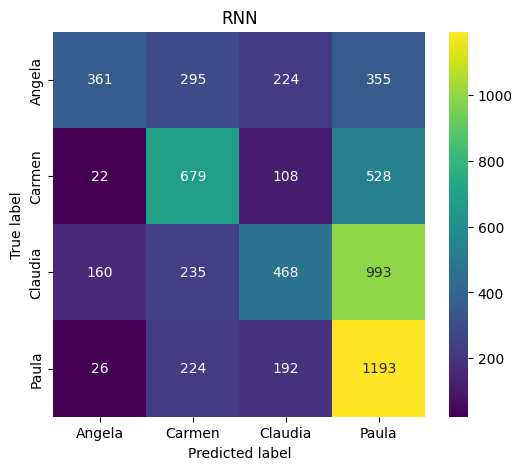

In [ ]:
# 5. EVALUACIÓN

loss_rnn, acc_rnn = model_rnn.evaluate(X_test_pad, y_test, verbose=0)

print(f"\nRNN - Loss: {loss_rnn:.4f}")
print(f"RNN - Accuracy: {acc_rnn:.4f}")

y_pred_probs = model_rnn.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification report RNN:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

plot_confusion(y_test, y_pred, "RNN", label_encoder.classes_)

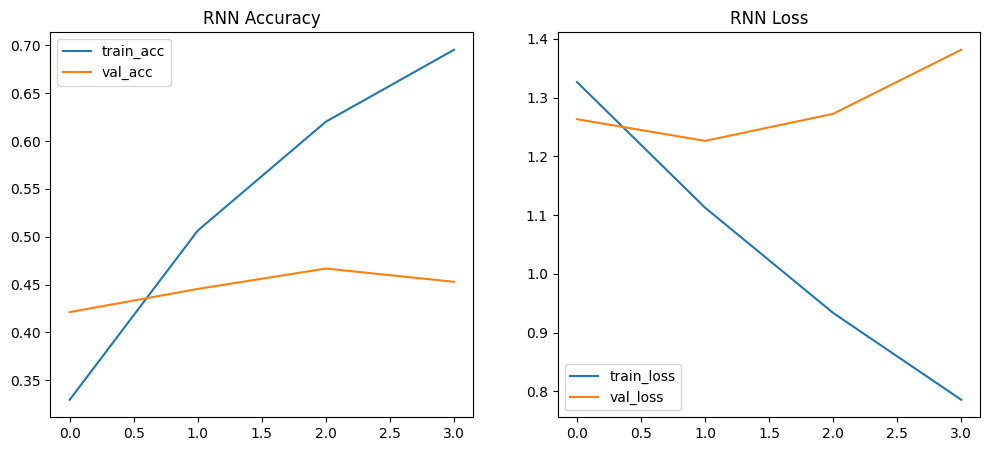

In [ ]:
# 6. CURVAS

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_rnn.history["accuracy"], label="train_acc")
plt.plot(history_rnn.history["val_accuracy"], label="val_acc")
plt.title("RNN Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_rnn.history["loss"], label="train_loss")
plt.plot(history_rnn.history["val_loss"], label="val_loss")
plt.title("RNN Loss")
plt.legend()

plt.show()

Tras ajustar los hiperparámetros del modelo, se observa una reducción del overfitting, evidenciada por una menor diferencia entre las curvas de entrenamiento y validación. Sin embargo, esta mejora en la generalización viene acompañada de una disminución en el rendimiento global del modelo (de aproximadamente 0,50 a 0,44). Esto sugiere que el modelo RNN presenta limitaciones inherentes para esta tarea, incluso tras la optimización de sus hiperparámetros.

## 3º RNN

Adicionalmente, se ha probado a ajustar el modelo utilizando una división secuencial de los datos en lugar de aleatoria, con el objetivo comprobar si respetando el orden temporal de los mensajes se obtendrían mejores resultados.

In [ ]:
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df["message_combined"].astype(str).reset_index(drop=True)
X_test = test_df["message_combined"].astype(str).reset_index(drop=True)

y_train = train_df["label"].reset_index(drop=True)
y_test = test_df["label"].reset_index(drop=True)

In [ ]:
# 1. TOKENIZER

max_words = 10000
max_len = 20

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

vocab_size = min(max_words, len(tokenizer.word_index) + 1)

print("Vocab size:", vocab_size)

Vocab size: 10000


In [ ]:
# 2. MODELO RNN

tf.keras.backend.clear_session()

model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, input_length=max_len),
    SimpleRNN(64),

    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(len(set(y_train)), activation="softmax")
])

model_rnn.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


# 3. EARLY STOPPING

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


# 4. ENTRENAMIENTO

history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

model_rnn.summary()

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


758/758 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.3447 - loss: 1.3158 - val_accuracy: 0.3921 - val_loss: 1.2660
Epoch 2/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.5161 - loss: 1.0904 - val_accuracy: 0.4326 - val_loss: 1.2629
Epoch 3/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.6467 - loss: 0.8667 - val_accuracy: 0.4463 - val_loss: 1.3097
Epoch 4/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.7356 - loss: 0.6828 - val_accuracy: 0.4372 - val_loss: 1.4774
Epoch 5/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.7791 - loss: 0.5661 - val_accuracy: 0.4321 - val_loss: 1.7245


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,044,942 (11.62 MB)

 Trainable params: 1,014,980 (3.87 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,029,962 (7.74 MB)


RNN - Loss: 1.2629
RNN - Accuracy: 0.4326
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification report RNN:
              precision    recall  f1-score   support

      Angela       0.62      0.32      0.42      1235
      Carmen       0.63      0.28      0.39      1337
     Claudia       0.39      0.51      0.44      1856
       Paula       0.38      0.55      0.45      1635

    accuracy                           0.43      6063
   macro avg       0.50      0.42      0.42      6063
weighted avg       0.49      0.43      0.43      6063



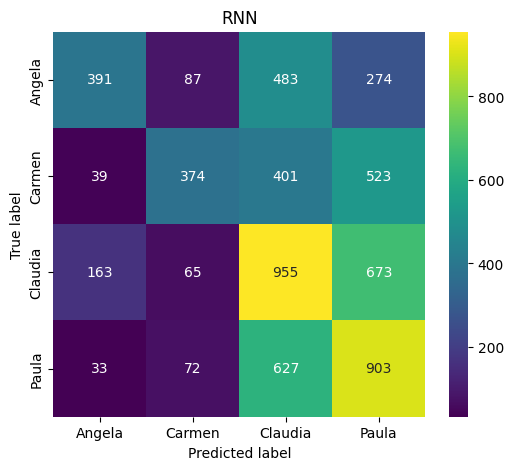

In [ ]:
# 5. EVALUACIÓN

loss_rnn, acc_rnn = model_rnn.evaluate(X_test_pad, y_test, verbose=0)

print(f"\nRNN - Loss: {loss_rnn:.4f}")
print(f"RNN - Accuracy: {acc_rnn:.4f}")

y_pred_probs = model_rnn.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification report RNN:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

plot_confusion(y_test, y_pred, "RNN", label_encoder.classes_)

Esta estrategia ha dado lugar a un menor rendimiento en términos de accuracy en el conjunto de validación, pasando de aproximadamente 0,50 a 0,43, lo que indica una mayor dificultad del modelo para generalizar en un contexto que parecía ser más realista.

En conclusión, aunque las RNN incorporan memoria de estados anteriores, en la práctica presentan dificultades para mantener dependencias a largo plazo debido al problema del gradiente desvanecido, lo que limita su rendimiento. Es por esto que se recurren arquitecturas más avanzadas como LSTM.

## 1º LSTM

In [ ]:
# 2. MODELO LSTM

tf.keras.backend.clear_session()

model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),

    LSTM(64, return_sequences=True),
    Dropout(0.5),

    LSTM(32),
    Dropout(0.5),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(len(set(y_train)), activation="softmax")
])

from tensorflow.keras.optimizers import Adam

model_lstm.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=0.0005),
    metrics=["accuracy"]
)


# 3. EARLY STOPPING

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


# 4. ENTRENAMIENTO
# -----------------------------
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 74s 86ms/step - accuracy: 0.3508 - loss: 1.2983 - val_accuracy: 0.3904 - val_loss: 1.2624
Epoch 2/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - accuracy: 0.5226 - loss: 1.0869 - val_accuracy: 0.4976 - val_loss: 1.1905
Epoch 3/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.6457 - loss: 0.8908 - val_accuracy: 0.5087 - val_loss: 1.2484
Epoch 4/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 64s 85ms/step - accuracy: 0.6972 - loss: 0.7818 - val_accuracy: 0.5156 - val_loss: 1.2767


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,032,590 (15.38 MB)

 Trainable params: 1,344,196 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,688,394 (10.26 MB)


LSTM - Loss: 1.1905
LSTM - Accuracy: 0.4976
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step

Classification report LSTM:
              precision    recall  f1-score   support

      Angela       0.55      0.39      0.46      1235
      Carmen       0.52      0.56      0.54      1337
     Claudia       0.45      0.45      0.45      1856
       Paula       0.51      0.59      0.55      1635

    accuracy                           0.50      6063
   macro avg       0.51      0.50      0.50      6063
weighted avg       0.50      0.50      0.50      6063



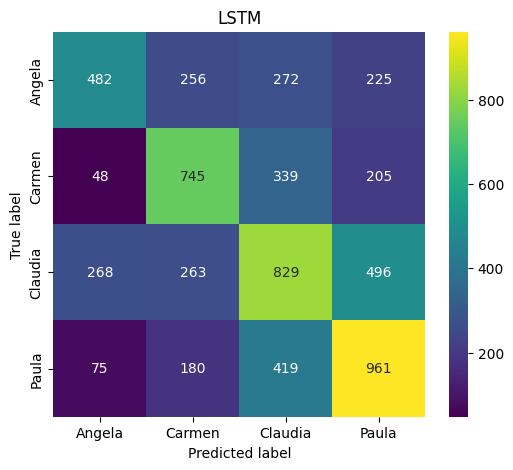

In [ ]:
# 5. EVALUACIÓN

loss_lstm, acc_lstm = model_lstm.evaluate(X_test_pad, y_test, verbose=0)

print(f"\nLSTM - Loss: {loss_lstm:.4f}")
print(f"LSTM - Accuracy: {acc_lstm:.4f}")

y_pred_probs = model_lstm.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification report LSTM:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

plot_confusion(y_test, y_pred, "LSTM", label_encoder.classes_)

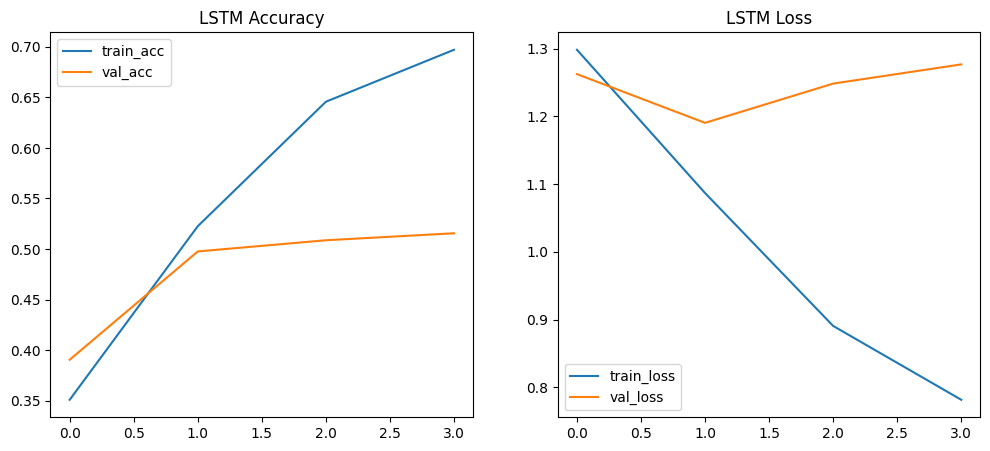

In [ ]:
# 6. CURVAS

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_lstm.history["accuracy"], label="train_acc")
plt.plot(history_lstm.history["val_accuracy"], label="val_acc")
plt.title("LSTM Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history["loss"], label="train_loss")
plt.plot(history_lstm.history["val_loss"], label="val_loss")
plt.title("LSTM Loss")
plt.legend()

plt.show()

En este modelo LSTM se introducen mejoras respecto al RNN, como el uso de múltiples capas LSTM, un mayor valor de dropout y el ajuste del learning rate, lo que permite un entrenamiento más estable y contribuye a reducir el overfitting. Esto se refleja en unas curvas de entrenamiento y validación más cercanas, indicando una mejor generalización del modelo. Sin embargo, el rendimiento en términos de accuracy se mantiene en torno a 0,50, similar al obtenido con RNN.

## 2º LSTM

Por último, se considera probar distintas configuraciones del tokenizador, ajustando parámetros como el tamaño del vocabulario y la longitud máxima de las secuencias, con el objetivo de analizar si mejora el rendimiento del modelo.

In [ ]:
# TOKENIZER

max_words = 5000
max_len = 30

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

vocab_size = min(max_words, len(tokenizer.word_index) + 1)

print("Vocab size:", vocab_size)

In [ ]:
# 2. MODELO LSTM

tf.keras.backend.clear_session()

model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, input_length=max_len),
    LSTM(64),

    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(len(set(y_train)), activation="softmax")
])

model_lstm.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


# 3. EARLY STOPPING

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


# 4. ENTRENAMIENTO
# -----------------------------
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

model_lstm.summary()

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


758/758 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.3330 - loss: 1.3233 - val_accuracy: 0.4113 - val_loss: 1.2398
Epoch 2/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.4791 - loss: 1.1156 - val_accuracy: 0.4697 - val_loss: 1.1756
Epoch 3/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.5575 - loss: 0.9818 - val_accuracy: 0.4775 - val_loss: 1.2221
Epoch 4/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.6156 - loss: 0.8871 - val_accuracy: 0.4993 - val_loss: 1.2498
Epoch 5/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.6573 - loss: 0.8043 - val_accuracy: 0.5049 - val_loss: 1.2772


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 100)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,639,982 (6.26 MB)

 Trainable params: 546,660 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,093,322 (4.17 MB)


LSTM - Loss: 1.1756
LSTM - Accuracy: 0.4697
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step

Classification report LSTM:
              precision    recall  f1-score   support

      Angela       0.56      0.38      0.45      1235
      Carmen       0.58      0.53      0.56      1337
     Claudia       0.36      0.49      0.41      1856
       Paula       0.51      0.47      0.49      1635

    accuracy                           0.47      6063
   macro avg       0.50      0.47      0.48      6063
weighted avg       0.49      0.47      0.47      6063



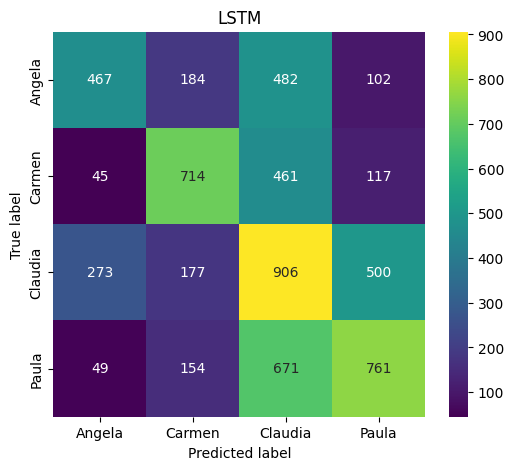

In [ ]:
# 5. EVALUACIÓN

loss_lstm, acc_lstm = model_lstm.evaluate(X_test_pad, y_test, verbose=0)

print(f"\nLSTM - Loss: {loss_lstm:.4f}")
print(f"LSTM - Accuracy: {acc_lstm:.4f}")

y_pred_probs = model_lstm.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification report LSTM:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

plot_confusion(y_test, y_pred, "LSTM", label_encoder.classes_)

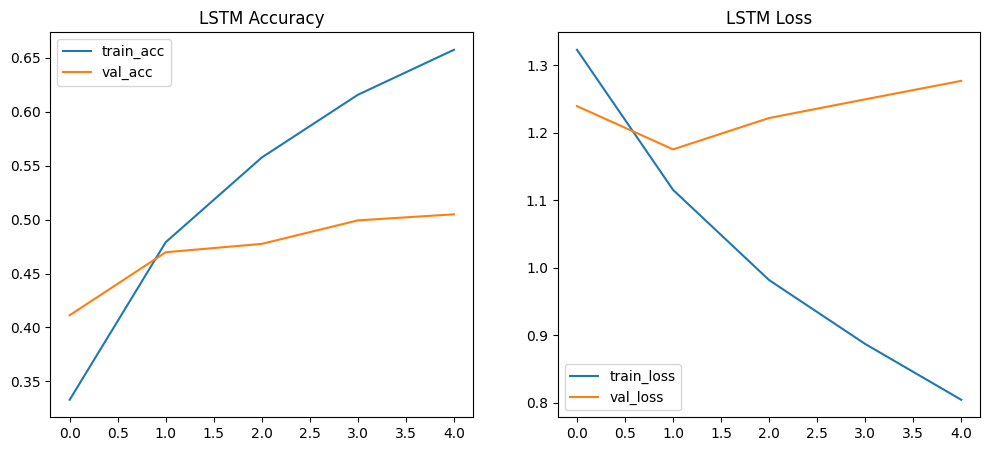

In [ ]:
# 6. CURVAS

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_lstm.history["accuracy"], label="train_acc")
plt.plot(history_lstm.history["val_accuracy"], label="val_acc")
plt.title("LSTM Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history["loss"], label="train_loss")
plt.plot(history_lstm.history["val_loss"], label="val_loss")
plt.title("LSTM Loss")
plt.legend()

plt.show()

No se observan mejoras en el rendimiento del modelo, lo que sugiere que la limitación no reside en el preprocesamiento del texto, sino en la propia naturaleza del problema.

Esto puede explicarse porque los modelos LSTM están especialmente diseñados para capturar dependencias a largo plazo en secuencias más largas, mientras que en este caso los mensajes son cortos y presentan un vocabulario muy similar entre usuarios. Por ello, se espera que modelos como GRU, más simples y eficientes en secuencias cortas, puedan ofrecer un mejor rendimiento en este problema.

## 1º GRU

In [ ]:
# 2. MODELO GRU

tf.keras.backend.clear_session()

model_gru = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),

    GRU(64, return_sequences=True),
    Dropout(0.3),

    GRU(32),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(len(set(y_train)), activation="softmax")
])

from tensorflow.keras.optimizers import Adam

model_gru.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=0.0005),
    metrics=["accuracy"]
)


# 3. EARLY STOPPING

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


# 4. ENTRENAMIENTO

history_gru = model_gru.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

model_gru.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 91s 97ms/step - accuracy: 0.3299 - loss: 1.3199 - val_accuracy: 0.3922 - val_loss: 1.2651
Epoch 2/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 66s 76ms/step - accuracy: 0.4794 - loss: 1.1086 - val_accuracy: 0.4613 - val_loss: 1.2346
Epoch 3/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 55s 73ms/step - accuracy: 0.5866 - loss: 0.9268 - val_accuracy: 0.4943 - val_loss: 1.2536
Epoch 4/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 62s 47ms/step - accuracy: 0.6669 - loss: 0.7910 - val_accuracy: 0.5054 - val_loss: 1.3056
Epoch 5/15
758/758 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - accuracy: 0.7154 - loss: 0.6901 - val_accuracy: 0.5116 - val_loss: 1.3896


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 20, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,987,086 (15.21 MB)

 Trainable params: 1,329,028 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,658,058 (10.14 MB)


GRU - Loss: 1.2346
GRU - Accuracy: 0.4613
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step

Classification report GRU:
              precision    recall  f1-score   support

      Angela       0.51      0.44      0.47      1235
      Carmen       0.65      0.40      0.49      1337
     Claudia       0.36      0.50      0.42      1856
       Paula       0.49      0.48      0.49      1635

    accuracy                           0.46      6063
   macro avg       0.50      0.46      0.47      6063
weighted avg       0.49      0.46      0.47      6063



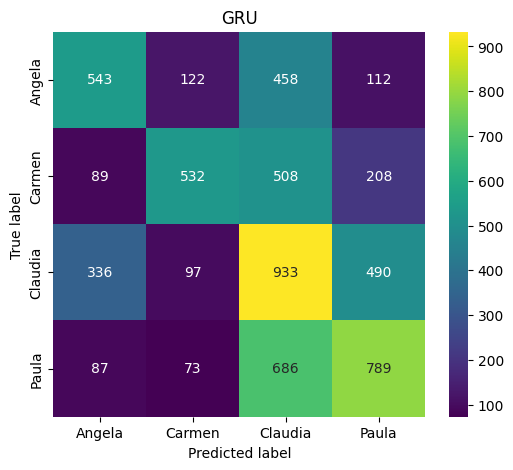

In [ ]:
# 5. EVALUACIÓN

loss_gru, acc_gru = model_gru.evaluate(X_test_pad, y_test, verbose=0)

print(f"\nGRU - Loss: {loss_gru:.4f}")
print(f"GRU - Accuracy: {acc_gru:.4f}")

y_pred_probs = model_gru.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification report GRU:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

plot_confusion(y_test, y_pred, "GRU", label_encoder.classes_)

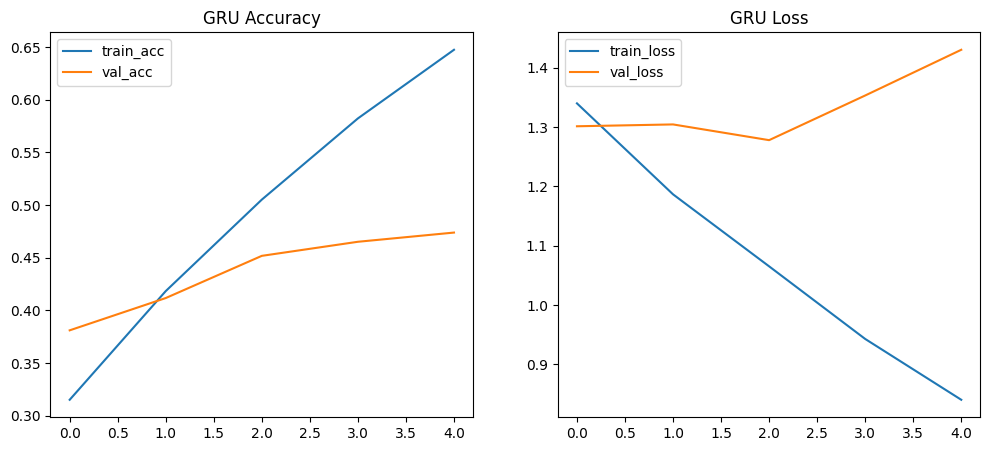

In [ ]:
# 6. CURVAS

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_gru.history["accuracy"], label="train_acc")
plt.plot(history_gru.history["val_accuracy"], label="val_acc")
plt.title("GRU Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_gru.history["loss"], label="train_loss")
plt.plot(history_gru.history["val_loss"], label="val_loss")
plt.title("GRU Loss")
plt.legend()

plt.show()

En el primer modelo GRU se parte de una arquitectura inicial compuesta por dos capas GRU, con un valor de patience de 3 y dropout de 0.3. Además, se introduce un learning rate más bajo, lo que contribuye a un entrenamiento más estable y a una reducción del overfitting, observándose una menor divergencia entre las curvas de entrenamiento y validación. Sin embargo, esta mejora en la generalización viene acompañada de una ligera disminución en el rendimiento del modelo, alcanzando una accuracy en validación de aproximadamente 0.46.

## 2º GRU

In [ ]:
# 2. MODELO GRU

tf.keras.backend.clear_session()

model_gru = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),

    GRU(64, return_sequences=True),
    Dropout(0.3),

    GRU(32),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(len(set(y_train)), activation="softmax")
])

from tensorflow.keras.optimizers import Adam

model_gru.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=0.0005),
    metrics=["accuracy"]
)


# 3. EARLY STOPPING

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


# 4. ENTRENAMIENTO

history_gru = model_gru.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=15,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

model_gru.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 137s 41ms/step - accuracy: 0.3730 - loss: 1.2718 - val_accuracy: 0.4339 - val_loss: 1.1991
Epoch 2/15
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 167s 49ms/step - accuracy: 0.5578 - loss: 0.9983 - val_accuracy: 0.5070 - val_loss: 1.1592
Epoch 3/15
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 182s 42ms/step - accuracy: 0.6675 - loss: 0.8094 - val_accuracy: 0.5146 - val_loss: 1.2151
Epoch 4/15
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 123s 40ms/step - accuracy: 0.7225 - loss: 0.6879 - val_accuracy: 0.5209 - val_loss: 1.2966
Epoch 5/15
3032/3032 ━━━━━━━━━━━━━━━━━━━━ 136s 45ms/step - accuracy: 0.7545 - loss: 0.5994 - val_accuracy: 0.5205 - val_loss: 1.3968


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 20, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,987,086 (15.21 MB)

 Trainable params: 1,329,028 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,658,058 (10.14 MB)


GRU - Loss: 1.1592
GRU - Accuracy: 0.5070
190/190 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step

Classification report GRU:
              precision    recall  f1-score   support

      Angela       0.56      0.37      0.44      1235
      Carmen       0.56      0.56      0.56      1337
     Claudia       0.43      0.58      0.50      1856
       Paula       0.55      0.49      0.52      1635

    accuracy                           0.51      6063
   macro avg       0.53      0.50      0.50      6063
weighted avg       0.52      0.51      0.51      6063



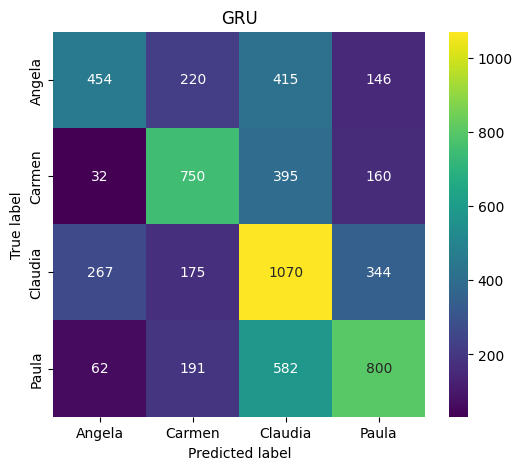

In [ ]:
# 5. EVALUACIÓN

loss_gru, acc_gru = model_gru.evaluate(X_test_pad, y_test, verbose=0)

print(f"\nGRU - Loss: {loss_gru:.4f}")
print(f"GRU - Accuracy: {acc_gru:.4f}")

y_pred_probs = model_gru.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification report GRU:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

plot_confusion(y_test, y_pred, "GRU", label_encoder.classes_)

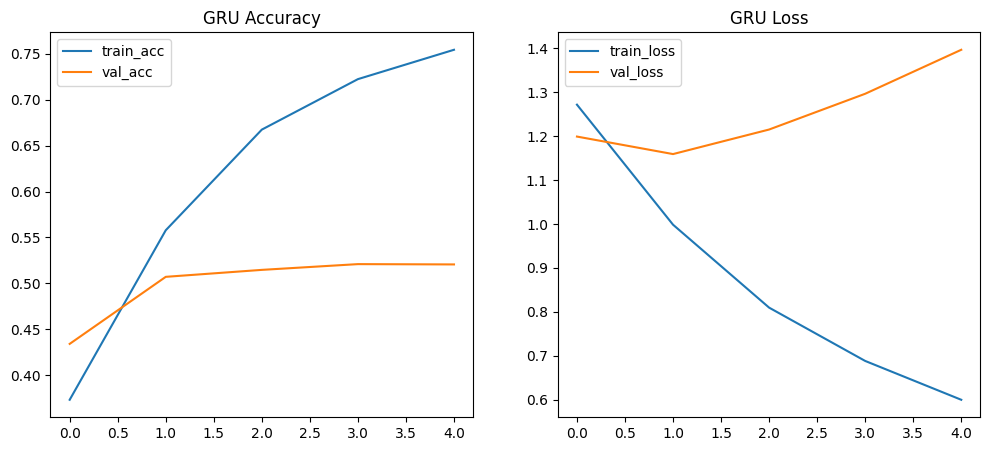

In [ ]:
# 6. CURVAS

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_gru.history["accuracy"], label="train_acc")
plt.plot(history_gru.history["val_accuracy"], label="val_acc")
plt.title("GRU Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_gru.history["loss"], label="train_loss")
plt.plot(history_gru.history["val_loss"], label="val_loss")
plt.title("GRU Loss")
plt.legend()

plt.show()

En esta segunda configuración del modelo GRU, se reduce el tamaño del batch de 32 a 8, lo que permite al modelo aprender de forma más detallada y mejora el rendimiento en validación, alcanzando una accuracy de aproximadamente 0.51. Sin embargo, este cambio también provoca un aumento del overfitting, evidenciado por una mayor separación entre las curvas de entrenamiento y validación. Esto refleja el compromiso habitual entre rendimiento y capacidad de generalización en modelos de Deep Learning.

## 1º Transformer

A diferencia de los modelos RNN, LSTM y GRU, que se entrenan desde cero con los datos disponibles, en los modelos Transformer se aplica fine-tuning, partiendo de un modelo preentrenado que ya ha aprendido representaciones generales del lenguaje.

In [15]:
# 1. TOKENIZER TRANSFORMER

model_name = "distilbert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)


# 2. DATASET

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=64
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = TextDataset(X_train.tolist(), y_train.tolist())
test_dataset = TextDataset(X_test.tolist(), y_test.tolist())


# 3. MODELO

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)


# 4. MÉTRICAS

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

# 5. TRAINING

training_args = TrainingArguments(
    output_dir="./transformer",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

# -----------------------------
# 6. EVALUACIÓN
# -----------------------------
preds_output = trainer.predict(test_dataset)

y_pred = np.argmax(preds_output.predictions, axis=1)

print("\nTransformer Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.102303,0.963731,0.584034
2,0.833798,0.928751,0.614877
3,0.607738,1.064025,0.618011



Transformer Accuracy: 0.6180108857001484

Classification report:
              precision    recall  f1-score   support

      Angela       0.69      0.62      0.65      1158
      Carmen       0.62      0.62      0.62      1444
     Claudia       0.61      0.59      0.60      1774
       Paula       0.59      0.64      0.61      1687

    accuracy                           0.62      6063
   macro avg       0.63      0.62      0.62      6063
weighted avg       0.62      0.62      0.62      6063



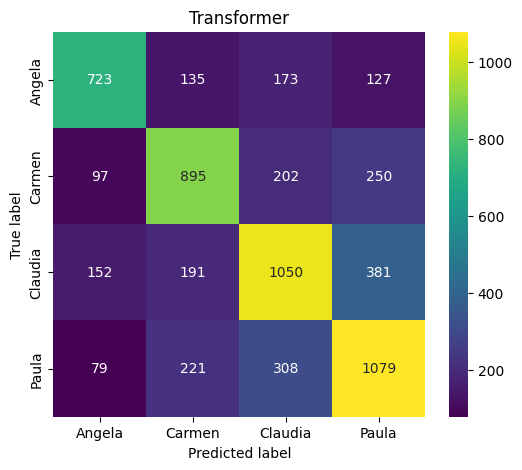

In [16]:
y_pred = np.argmax(preds_output.predictions, axis=1)

plot_confusion(y_test, y_pred, "Transformer", label_encoder.classes_)

El modelo Transformer alcanza un rendimiento superior al resto de modelos, con una accuracy cercana al 0.62 y métricas equilibradas entre clases. En comparación con el modelo RNN inicial, donde se observaba una elevada confusión especialmente entre Claudia y Paula, el Transformer reduce notablemente estos errores. Aunque sigue existiendo cierta confusión entre ambas clases, como reflejan los valores fuera de la diagonal en la matriz de confusión, el número de aciertos en general aumenta significativamente en las cuatro clases, lo que indica una mejor capacidad para captar patrones más complejos en el lenguaje. Esto confirma que los modelos basados en atención son más eficaces para diferenciar estilos similares que los modelos secuenciales tradicionales.

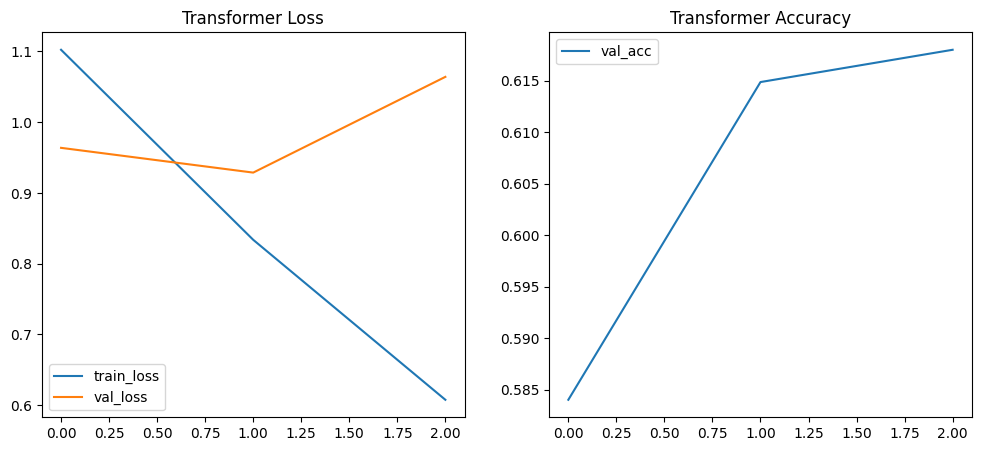

In [19]:
logs = trainer.state.log_history
df_logs = pd.DataFrame(logs)

# separar train y eval
train_loss = df_logs[df_logs["loss"].notna()]
eval_logs = df_logs[df_logs["eval_loss"].notna()]

plt.figure(figsize=(12,5))

# LOSS

plt.subplot(1,2,1)
plt.plot(train_loss["loss"].values, label="train_loss")

if not eval_logs.empty:
    plt.plot(eval_logs["eval_loss"].values, label="val_loss")

plt.title("Transformer Loss")
plt.legend()

# ACCURACY

plt.subplot(1,2,2)

if "eval_accuracy" in eval_logs:
    plt.plot(eval_logs["eval_accuracy"].values, label="val_acc")

plt.title("Transformer Accuracy")
plt.legend()

plt.show()

Se observa que el modelo sigue mejorando con más épocas de entrenamiento, lo que indica que aún no ha alcanzado su convergencia.

In [18]:
model.save_pretrained("/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/TRABAJO_NO_ESTRUCTURADOS/models/transformer1")
tokenizer.save_pretrained("/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/TRABAJO_NO_ESTRUCTURADOS/models/transformer1")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/TRABAJO_NO_ESTRUCTURADOS/models/transformer1/tokenizer_config.json',
 '/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/TRABAJO_NO_ESTRUCTURADOS/models/transformer1/tokenizer.json')

## 2º Transformer

In [20]:
# 1. TOKENIZER TRANSFORMER

model_name = "distilbert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)


# 2. DATASET

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=64
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = TextDataset(X_train.tolist(), y_train.tolist())
test_dataset = TextDataset(X_test.tolist(), y_test.tolist())


# 3. MODELO

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)


# 4. MÉTRICAS

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

# 5. TRAINING

training_args = TrainingArguments(
    output_dir="./transformer",
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

# -----------------------------
# 6. EVALUACIÓN
# -----------------------------
preds_output = trainer.predict(test_dataset)

y_pred = np.argmax(preds_output.predictions, axis=1)

print("\nTransformer Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.102911,0.983614,0.576282
2,0.851895,0.940232,0.614052
3,0.674160,1.051584,0.609434
4,0.531058,1.196527,0.611578
5,0.426455,1.357688,0.612568



Transformer Accuracy: 0.6125680356259278

Classification report:
              precision    recall  f1-score   support

      Angela       0.68      0.64      0.66      1158
      Carmen       0.60      0.61      0.61      1444
     Claudia       0.62      0.55      0.59      1774
       Paula       0.57      0.66      0.61      1687

    accuracy                           0.61      6063
   macro avg       0.62      0.62      0.62      6063
weighted avg       0.62      0.61      0.61      6063



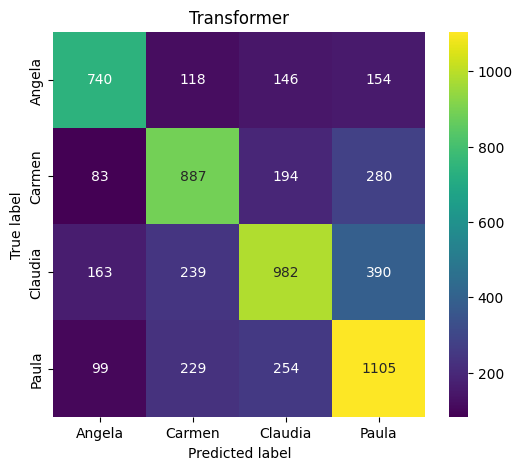

In [21]:
y_pred = np.argmax(preds_output.predictions, axis=1)

plot_confusion(y_test, y_pred, "Transformer", label_encoder.classes_)

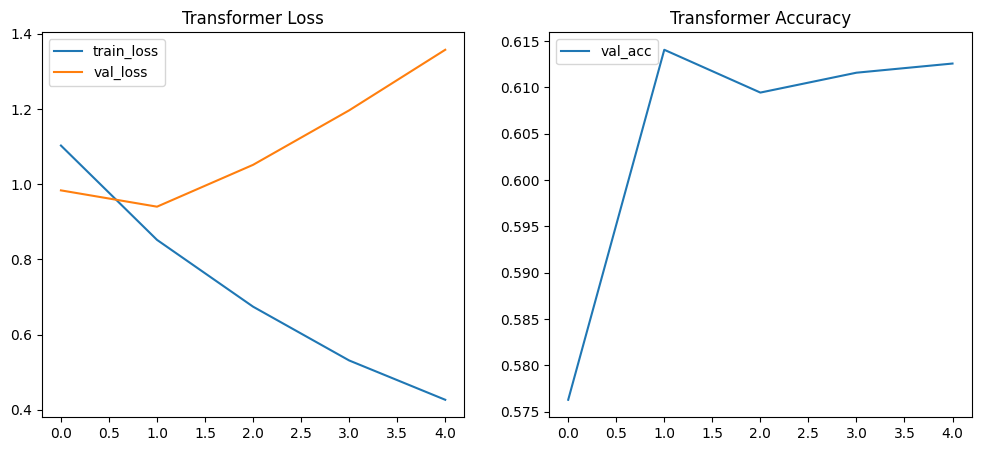

In [22]:
logs = trainer.state.log_history
df_logs = pd.DataFrame(logs)

# separar train y eval
train_loss = df_logs[df_logs["loss"].notna()]
eval_logs = df_logs[df_logs["eval_loss"].notna()]

plt.figure(figsize=(12,5))

# LOSS

plt.subplot(1,2,1)
plt.plot(train_loss["loss"].values, label="train_loss")

if not eval_logs.empty:
    plt.plot(eval_logs["eval_loss"].values, label="val_loss")

plt.title("Transformer Loss")
plt.legend()

# ACCURACY

plt.subplot(1,2,2)

if "eval_accuracy" in eval_logs:
    plt.plot(eval_logs["eval_accuracy"].values, label="val_acc")

plt.title("Transformer Accuracy")
plt.legend()

plt.show()

El resultado no es el que se esperaba, el modelo no sigue aprendiendo con más épocas, al contrario, este alcanza su mejor rendimiento en las primeras épocas, concretamente en la segunda, a partir de la cual comienza a mostrar signos de overfitting, evidenciados por el aumento de la pérdida en validación.

El resultado no es el que se esperaba, el modelo no sigue aprendiendo con más épocas, al contrario, este alcanza su mejor rendimiento en las primeras épocas. A partir de la segunda comienza a mostrar signos de overfitting, evidenciados por el aumento de la pérdida en validación. Aunque, observando los gráficos del modelo anterior, en la época 3 se obtiene el mayor rendimiento en accuracy y una muy leve subida de la pérdida. Por tanto de momento nos quedaremos con ese modelo, el Transformer 1 que presenta un 0,61 de accuracy.

## 3º Transformer

Por último, se evalúa un modelo Transformer preentrenado en español con el objetivo de comprobar si el uso de un modelo específico del idioma ofrece un mejor rendimiento que el modelo multilingüe empleado previamente. Asimismo, se implementa la técnica de early stopping, que permite detener el entrenamiento cuando no se observan mejoras en validación, garantizando la selección del mejor modelo y reduciendo el riesgo de sobreajuste.

In [40]:
# 1. TOKENIZER

model_name = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)


# 2. DATASET

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=64
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


train_dataset = TextDataset(X_train.tolist(), y_train.tolist())
test_dataset  = TextDataset(X_test.tolist(), y_test.tolist())


# 3. MODELO

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)


# 4. MÉTRICAS

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}


# 5. TRAINING (EARLY STOPPING)

training_args = TrainingArguments(
    output_dir="./transformer_es",

    num_train_epochs=6,
    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    report_to="none"
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


# 6. ENTRENAR

trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Epoch,Training Loss,Validation Loss,Accuracy
1,1.079084,0.946559,0.598878
2,0.816998,0.952808,0.606960
3,0.593261,1.107166,0.627577
4,0.425690,1.385046,0.622629
5,0.314494,1.814783,0.624608


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=15160, training_loss=0.6459053381766368, metrics={'train_runtime': 1969.9839, 'train_samples_per_second': 73.862, 'train_steps_per_second': 9.235, 'total_flos': 3988012989442560.0, 'train_loss': 0.6459053381766368, 'epoch': 5.0})


Transformer ES - Accuracy: 0.6274121721919842

Classification report:
              precision    recall  f1-score   support

      Angela       0.79      0.58      0.67      1158
      Carmen       0.64      0.58      0.61      1444
     Claudia       0.62      0.62      0.62      1774
       Paula       0.56      0.70      0.62      1687

    accuracy                           0.63      6063
   macro avg       0.65      0.62      0.63      6063
weighted avg       0.64      0.63      0.63      6063



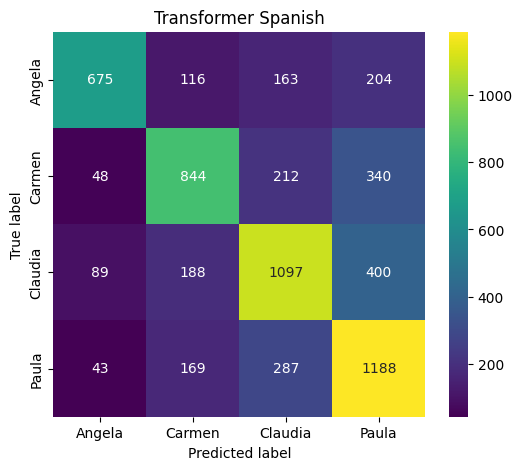

In [41]:

# -----------------------------
# 7. EVALUACIÓN FINAL
# -----------------------------
preds_output = trainer.predict(test_dataset)

y_pred = np.argmax(preds_output.predictions, axis=1)

print("\nTransformer ES - Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


# -----------------------------
# 8. MATRIZ DE CONFUSIÓN
# -----------------------------
plot_confusion(y_test, y_pred, "Transformer Spanish", label_encoder.classes_)

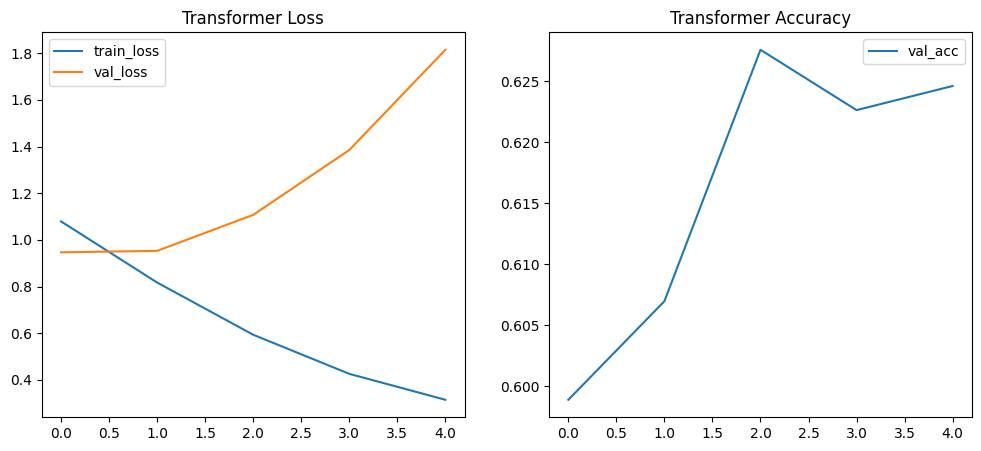

In [43]:
logs = trainer.state.log_history
df_logs = pd.DataFrame(logs)

# separar train y eval
train_loss = df_logs[df_logs["loss"].notna()]
eval_logs = df_logs[df_logs["eval_loss"].notna()]

plt.figure(figsize=(12,5))

# LOSS

plt.subplot(1,2,1)
plt.plot(train_loss["loss"].values, label="train_loss")

if not eval_logs.empty:
    plt.plot(eval_logs["eval_loss"].values, label="val_loss")

plt.title("Transformer Loss")
plt.legend()

# ACCURACY

plt.subplot(1,2,2)

if "eval_accuracy" in eval_logs:
    plt.plot(eval_logs["eval_accuracy"].values, label="val_acc")

plt.title("Transformer Accuracy")
plt.legend()

plt.show()

In [42]:
save_path = "/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/TRABAJO_NO_ESTRUCTURADOS/models/transformer_spanish"

trainer.model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/TRABAJO_NO_ESTRUCTURADOS/models/transformer_spanish/tokenizer_config.json',
 '/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/TRABAJO_NO_ESTRUCTURADOS/models/transformer_spanish/tokenizer.json')

# CONCLUSIÓN

El modelo Transformer preentrenado en español alcanza el mejor rendimiento de todos los modelos evaluados, con una accuracy aproximada del 0.63, mejorando los resultados obtenidos con el modelo multilingüe. Además, gracias al uso de early stopping, el entrenamiento se detiene automáticamente en la época óptima, evitando el sobreajuste.

La matriz de confusión muestra una mejora significativa respecto a modelos anteriores, especialmente en la diferenciación entre Claudia y Paula, que previamente presentaban una alta tasa de confusión. En este caso, se incrementa notablemente el número de aciertos en ambas clases, lo que indica una mejor capacidad del modelo para capturar patrones más complejos del lenguaje.

En conjunto, estos resultados confirman que el uso de modelos preentrenados específicos del idioma permite mejorar el rendimiento en tareas de clasificación de texto, especialmente cuando existen similitudes entre las clases. Además, el uso de modelos Transformer resulta más adecuado frente a los modelos secuenciales tradicionales, ya que incorporan mecanismos de atención que permiten capturar mejor el contexto completo del texto, junto con el aprovechamiento de un conocimiento previo adquirido durante el preentrenamiento (fine-tuning). Por otro lado, cabe destacar la importancia de una adecuada selección de hiperparámetros, que resulta clave para encontrar el mejor equilibrio entre rendimiento y generalización del modelo.

## Pruebas de clasificación

Finalmente, se han realizado algunas pruebas cualitativas para analizar cómo clasifica el modelo nuevos mensajes, utilizando frases representativas que podrían ser escritas por las distintas participantes.

In [5]:
path = "/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/TRABAJO_NO_ESTRUCTURADOS/models/transformer_spanish"

tokenizer = AutoTokenizer.from_pretrained(path)
model = AutoModelForSequenceClassification.from_pretrained(path)

model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31002, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [6]:
def predict_text(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    )

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    probs = torch.softmax(logits, dim=1).numpy()[0]

    pred_class = np.argmax(probs)
    pred_label = label_encoder.classes_[pred_class]

    return pred_label, probs

In [25]:
examples = [
    "bro, no me metais prisa",
    "vale perfecto entonces quedamos a las 9",
    "jajajaja me meo",
    "no puedo hoy estoy liada",
]

for text in examples:
    label, probs = predict_text(text)

    print(f"\nTexto: {text}")
    print(f"Predicción: {label}")

    for i, clase in enumerate(label_encoder.classes_):
        print(f"{clase}: {probs[i]:.3f}")


Texto: bro, no me metais prisa
Predicción: Paula
Angela: 0.005
Carmen: 0.045
Claudia: 0.341
Paula: 0.609

Texto: vale perfecto entonces quedamos a las 9
Predicción: Paula
Angela: 0.002
Carmen: 0.001
Claudia: 0.004
Paula: 0.992

Texto: jajajaja me meo
Predicción: Claudia
Angela: 0.294
Carmen: 0.033
Claudia: 0.662
Paula: 0.010

Texto: no puedo hoy estoy liada
Predicción: Paula
Angela: 0.090
Carmen: 0.003
Claudia: 0.258
Paula: 0.649


In [17]:
examples = [
    "chicas hay que organizar el viaje",
    "mmm yo creo que no puedo",
    "bff es que tengo mucho que hacer",
    "a que hora comemos que tengo hambre!",
    "perdoon que no se resumir jaja"
]

for text in examples:
    label, probs = predict_text(text)

    print(f"\nTexto: {text}")
    print(f"Predicción: {label}")

    for i, clase in enumerate(label_encoder.classes_):
        print(f"{clase}: {probs[i]:.3f}")


Texto: chicas hay que organizar el viaje
Predicción: Paula
Angela: 0.007
Carmen: 0.001
Claudia: 0.009
Paula: 0.984

Texto: mmm yo creo que no puedo
Predicción: Claudia
Angela: 0.002
Carmen: 0.001
Claudia: 0.996
Paula: 0.002

Texto: bff es que tengo mucho que hacer
Predicción: Paula
Angela: 0.002
Carmen: 0.005
Claudia: 0.130
Paula: 0.863

Texto: a que hora comemos que tengo hambre!
Predicción: Paula
Angela: 0.001
Carmen: 0.001
Claudia: 0.005
Paula: 0.993

Texto: perdoon que no se resumir jaja
Predicción: Carmen
Angela: 0.002
Carmen: 0.993
Claudia: 0.004
Paula: 0.001


Probamos también con el modelo multi-lenguaje para comparar resultados:

In [27]:
# cargar desde Drive
path = "/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/TRABAJO_NO_ESTRUCTURADOS/models/transformer1"

tokenizer = AutoTokenizer.from_pretrained(path)
model = AutoModelForSequenceClassification.from_pretrained(path)

model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)

In [39]:
examples = [
    "bro, no me metais prisa",
    "vale perfecto entonces quedamos a las 9",
    "jajajaja me meo",
    "no puedo hoy estoy liada",
]

for text in examples:
    label, probs = predict_text(text)

    print(f"\nTexto: {text}")
    print(f"Predicción: {label}")

    for i, clase in enumerate(label_encoder.classes_):
        print(f"{clase}: {probs[i]:.3f}")


Texto: bro, no me metais prisa
Predicción: Claudia
Angela: 0.007
Carmen: 0.025
Claudia: 0.958
Paula: 0.010

Texto: vale perfecto entonces quedamos a las 9
Predicción: Paula
Angela: 0.086
Carmen: 0.036
Claudia: 0.316
Paula: 0.561

Texto: jajajaja me meo
Predicción: Claudia
Angela: 0.247
Carmen: 0.292
Claudia: 0.333
Paula: 0.127

Texto: no puedo hoy estoy liada
Predicción: Angela
Angela: 0.599
Carmen: 0.032
Claudia: 0.181
Paula: 0.188


In [37]:
examples = [
    "chicas hay que organizar el viaje",
    "mmm yo creo que no puedo",
    "bff es que tengo mucho que hacer",
    "a que hora comemos que tengo hambre!",
    "perdoon que no se resumir jaja"
]

for text in examples:
    label, probs = predict_text(text)

    print(f"\nTexto: {text}")
    print(f"Predicción: {label}")

    for i, clase in enumerate(label_encoder.classes_):
        print(f"{clase}: {probs[i]:.3f}")


Texto: chicas hay que organizar el viaje
Predicción: Paula
Angela: 0.003
Carmen: 0.005
Claudia: 0.007
Paula: 0.984

Texto: mmm yo creo que no puedo
Predicción: Claudia
Angela: 0.001
Carmen: 0.006
Claudia: 0.990
Paula: 0.002

Texto: bff es que tengo mucho que hacer
Predicción: Paula
Angela: 0.001
Carmen: 0.016
Claudia: 0.028
Paula: 0.955

Texto: a que hora comemos que tengo hambre!
Predicción: Paula
Angela: 0.003
Carmen: 0.003
Claudia: 0.015
Paula: 0.979

Texto: perdoon que no se resumir jaja
Predicción: Carmen
Angela: 0.004
Carmen: 0.987
Claudia: 0.006
Paula: 0.003


## Resultados:

Se observa que ambos modelos (multilingüe y específico en español) presentan un comportamiento muy similar, coincidiendo en la mayoría de las predicciones y diferenciándose únicamente en un número reducido de casos. En concreto, de los ejemplos probados, únicamente se observan diferencias en dos de ellos. Cabe destacar que el modelo en español comete un error en el caso del mensaje “bro, no me metáis prisa”, una expresión muy característica de Claudia, clasificándolo como Paula. Este error puede explicarse por el uso de la palabra “bro”, que, al tratarse de un anglicismo, puede no ser interpretado de forma óptima por un modelo preentrenado exclusivamente en español, a diferencia del modelo multilingüe.

Además, se aprecia que en expresiones más generales, como “jajaja me meo” o “no puedo hoy estoy liada”, las probabilidades se reparten entre varias clases. Esto es coherente con la naturaleza del problema, ya que este tipo de mensajes son utilizados por varias participantes de forma similar, lo que dificulta su correcta clasificación. De hecho, expresiones como “no puedo, estoy liada” son habituales tanto en Paula como en Angela, lo que explica que incluso los modelos asignen distintas clases ante el mismo mensaje.

Por el contrario, en aquellos ejemplos más específicos y representativos de cada participante, el modelo muestra un comportamiento muy preciso. En este sentido, se observa que Paula tiende a organizar planes y expresarse de forma directa, Carmen suele extenderse más al hablar y pedir disculpas por no saber resumir, Angela se caracteriza por estar ocupada y no poder quedar en muchas ocasiones, y Claudia tiende a agobiarse con los planes o las situaciones de presión. En estos casos más distintivos, el modelo logra identificar correctamente a cada usuaria, lo que indica que es capaz de captar patrones de estilo bien definidos.

En conjunto, estos resultados evidencian que, aunque el modelo alcanza un buen rendimiento, no es posible obtener valores extremadamente altos de accuracy debido a la propia naturaleza del problema, donde muchos mensajes comparten un estilo similar entre distintas usuarias, lo que introduce un límite inherente en la capacidad de discriminación del modelo.